In [241]:
using Plots
using JLD2 
using Statistics, StatsBase
using GLM 
using DataFrames
using LaTeXStrings
using ColorSchemes
using Plots.PlotMeasures

# Scaling with T

In [22]:
exp_1_f = jldopen("T_scaling_NTS1.jld2", "r");
per_trial_res_exp1 = read(exp_1_f, "per_trial_res")
Ts = [10, 50, 100, 200, 500, 1000]
T_res_dict = Dict()
T_res_dict[10] = [per_trial_res_exp1[trial][1][2:end-1] for trial in 1:3]
T_res_dict[50] = [per_trial_res_exp1[trial][2][2:end-1] for trial in 1:3]
T_res_dict[100] = [per_trial_res_exp1[trial][3][2:end-1] for trial in 1:3]
T_res_dict[200] = [per_trial_res_exp1[trial][4][2:end-1] for trial in 1:3]
T_res_dict[500] = [per_trial_res_exp1[trial][5][2:end-1] for trial in 1:3]
T_res_dict[1000] = [per_trial_res_exp1[trial][6][2:end-1] for trial in 1:3]

3-element Vector{Vector{Float64}}:
 [17.209697008132935, 29.103830099105835, 29.950294971466064, 28.188988208770752, 22.69080400466919]
 [13.429096937179565, 30.91429901123047, 31.251325130462646, 30.832603931427002, 28.973551034927368]
 [16.214607000350952, 28.880818128585815, 29.456860065460205, 29.780189990997314, 29.902719020843506]

In [41]:
T10_mean_per_trial = mean.(T_res_dict[10])
T10_mean = mean(T10_mean_per_trial)
T10_sem = std(T10_mean_per_trial) # standard error of the means

T50_mean_per_trial = mean.(T_res_dict[50])
T50_mean = mean(T50_mean_per_trial)
T50_sem = std(T50_mean_per_trial)

T100_mean_per_trial = mean.(T_res_dict[100])
T100_mean = mean(T100_mean_per_trial)
T100_sem = std(T100_mean_per_trial) 

T200_mean_per_trial = mean.(T_res_dict[200])
T200_mean = mean(T200_mean_per_trial)
T200_sem = std(T200_mean_per_trial)

T500_mean_per_trial = mean.(T_res_dict[500])
T500_mean = mean(T500_mean_per_trial)
T500_sem = std(T500_mean_per_trial)

T1000_mean_per_trial = mean.(T_res_dict[1000])
T1000_mean = mean(T1000_mean_per_trial)
T1000_sem = std(T1000_mean_per_trial)

0.8937997221101696

In [82]:
mean_sweep_time_varyingT = [T10_mean, T50_mean, T100_mean, T200_mean, T500_mean, T1000_mean]
sem_sweep_time_varyingT = [T10_sem, T50_sem, T100_sem, T200_sem, T500_sem, T1000_sem]
df = DataFrame(
    log_T = log10.(Ts),
    log_mean_time = log10.(mean_sweep_time_varyingT)
)

Row,log_T,log_mean_time
,Float64,Float64
1,1.0,-0.862576
2,1.69897,0.0596181
3,2.0,0.357662
4,2.30103,0.674553
5,2.69897,1.08537
6,3.0,1.42246


In [67]:
model = lm(@formula(log_mean_time ~ log_T), df);
fitted_log_times = predict(model)
fitted_times = 10 .^ fitted_log_times

6-element Vector{Float64}:
  0.15884750731448152
  0.9700302147429878
  2.1145258243942946
  4.609361022032734
 12.912723493079293
 28.147872998588415

In [342]:
@show slope = coef(model)[2]
@show intercept = coef(model)[1]
@show r2_val = GLM.r2(model)

slope = (coef(model))[2] = 1.1242325893604874
intercept = (coef(model))[1] = -1.923252185230747
r2_val = GLM.r2(model) = 0.9963749330881174


0.9963749330881174

In [324]:
seaborn_muted = [
    "#4878D0",  # blue
    "#EE854A",  # orange  
    "#6ACC64",  # green
    "#D65F5F",  # red
    "#956CB4",  # purple
    "#82C6E2",  # light blue
    "#D5BB67",  # yellow/gold
    "#8C613C",  # brown
    "#DC7EC0",  # pink
    "#797979"   # gray
]

10-element Vector{String}:
 "#4878D0"
 "#EE854A"
 "#6ACC64"
 "#D65F5F"
 "#956CB4"
 "#82C6E2"
 "#D5BB67"
 "#8C613C"
 "#DC7EC0"
 "#797979"

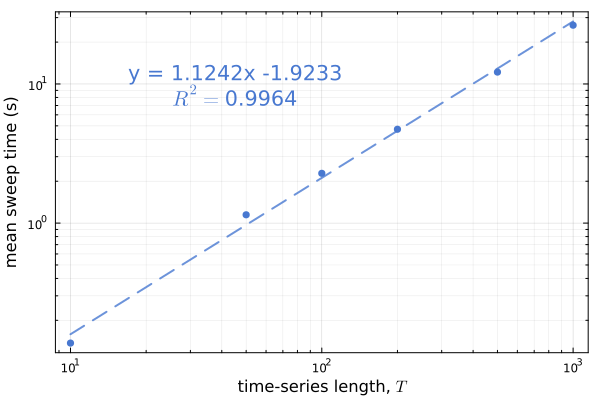

In [443]:
p1 = plot(Ts, fitted_times, label=:none, linewidth=2, color=seaborn_muted[1], alpha=0.8, ls=:dash)
scatter!(Ts, mean_sweep_time_varyingT, label=:none, xscale=:log10, yscale=:log10,
    xlabel="time-series length, " * L"T", ylabel="mean sweep time (s)", msw=0, c=seaborn_muted[1], 
    minorgrid=true, border=:box)
annotate!(45, 10, text("y = $(round(slope; digits=4))x $(round(intercept; digits=4))\n"*L"R^2 = " * "$(round(r2_val; digits=4))", seaborn_muted[1]))

# Scaling with # instances

In [112]:
exp_2_f = jldopen("Ninst_scaling_NTS1.jld2", "r");
per_trial_res_exp2 = read(exp_2_f, "per_trial_res_exp2")
Ninsts = [10, 50, 100, 200, 500, 1000];
Ninst_res_dict = Dict()
Ninst_res_dict[10] = [per_trial_res_exp2[trial][1][2:end-1] for trial in 1:3]
Ninst_res_dict[50] = [per_trial_res_exp2[trial][2][2:end-1] for trial in 1:3]
Ninst_res_dict[100] = [per_trial_res_exp2[trial][3][2:end-1] for trial in 1:3]
Ninst_res_dict[200] = [per_trial_res_exp2[trial][4][2:end-1] for trial in 1:3]
Ninst_res_dict[500] = [per_trial_res_exp2[trial][5][2:end-1] for trial in 1:3]
Ninst_res_dict[1000] = [per_trial_res_exp2[trial][6][2:end-1] for trial in 1:3]

3-element Vector{Vector{Float64}}:
 [10.456960916519165, 17.690394163131714, 17.363707065582275, 17.777956008911133, 17.3422749042511]
 [10.905559062957764, 17.086604118347168, 17.725233793258667, 17.79479718208313, 17.9459331035614]
 [10.738186120986938, 18.28307318687439, 17.529990911483765, 17.44432806968689, 17.84346890449524]

In [113]:
N_inst_10_mean_per_trial = mean.(Ninst_res_dict[10])
N_inst_10_mean = mean(N_inst_10_mean_per_trial)
N_inst_10_sem = std(N_inst_10_mean_per_trial) # standard error of the means

N_inst_50_mean_per_trial = mean.(Ninst_res_dict[50])
N_inst_50_mean = mean(N_inst_50_mean_per_trial)
N_inst_50_sem = std(N_inst_50_mean_per_trial)

N_inst_100_mean_per_trial = mean.(Ninst_res_dict[100])
N_inst_100_mean = mean(N_inst_100_mean_per_trial)
N_inst_100_sem = std(N_inst_100_mean_per_trial) 

N_inst_200_mean_per_trial = mean.(Ninst_res_dict[200])
N_inst_200_mean = mean(N_inst_200_mean_per_trial)
N_inst_200_sem = std(N_inst_200_mean_per_trial)

N_inst_500_mean_per_trial = mean.(Ninst_res_dict[500])
N_inst_500_mean = mean(N_inst_500_mean_per_trial)
N_inst_500_sem = std(N_inst_500_mean_per_trial)

N_inst_1000_mean_per_trial = mean.(Ninst_res_dict[1000])
N_inst_1000_mean = mean(N_inst_1000_mean_per_trial)
N_inst_1000_sem = std(N_inst_1000_mean_per_trial)

0.12348886167896984

In [114]:
mean_sweep_time_varying_Ninst = [N_inst_10_mean, N_inst_50_mean, N_inst_100_mean, N_inst_200_mean, N_inst_500_mean, N_inst_1000_mean]
sem_sweep_time_varying_Ninsts = [N_inst_10_sem, N_inst_50_sem, N_inst_100_sem, N_inst_200_sem, N_inst_500_sem, N_inst_1000_sem]
df2 = DataFrame(
    log_T = log10.(Ninsts),
    log_mean_time = log10.(mean_sweep_time_varying_Ninst)
)

Row,log_T,log_mean_time
,Float64,Float64
1,1.0,-0.520527
2,1.69897,0.227846
3,2.0,0.388552
4,2.30103,0.587796
5,2.69897,0.918137
6,3.0,1.21117


In [369]:
model2 = lm(@formula(log_mean_time ~ log_T), df2);
fitted_log_times2 = predict(model2)
fitted_times2 = 10 .^ fitted_log_times2;
@show slope2 = coef(model2)[2]
@show intercept2 = coef(model2)[1]
@show r2val2 = r2(model2)

slope2 = (coef(model2))[2] = 0.8322249447015287
intercept2 = (coef(model2))[1] = -1.2925706203485974
r2val2 = r2(model2) = 0.9901991181471995


0.9901991181471995

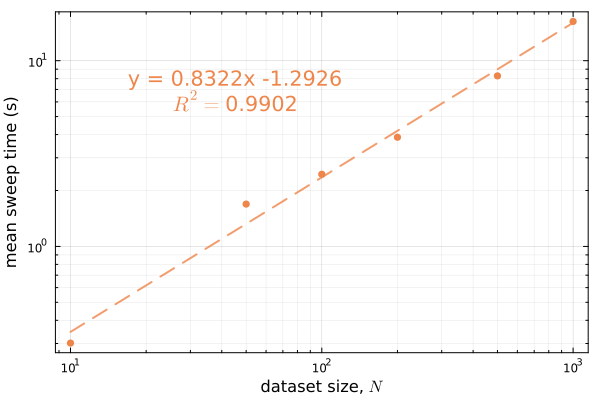

In [455]:
p2 = plot(Ninsts, fitted_times2, label=:none, linewidth=2, color=seaborn_muted[2], alpha=0.8, ls=:dash)
scatter!(Ninsts, mean_sweep_time_varying_Ninst, label=:none, xscale=:log10, yscale=:log10,
    xlabel="dataset size, " * L"N", ylabel="mean sweep time (s)", msw=0, c=seaborn_muted[2], minorgrid=true,border=:box)
annotate!(45, 7, text("y = $(round(slope2; digits=4))x $(round(intercept2; digits=4))\n"*L"R^2 = " * "$(round(r2val2; digits=4))", seaborn_muted[2]))

# Chi Max Scaling

In [154]:
exp_3_f = jldopen("chi_scaling_NTS1.jld2", "r");
per_trial_res_exp3 = read(exp_3_f, "per_trial_res_exp3")
chis = [5, 10, 20, 40, 60, 80, 100, 120, 150, 180]
chi_res_dict = Dict()
chi_res_dict[5] = [per_trial_res_exp3[trial][1][2:end-1] for trial in 1:3]
chi_res_dict[10] = [per_trial_res_exp3[trial][2][2:end-1] for trial in 1:3]
chi_res_dict[20] = [per_trial_res_exp3[trial][3][2:end-1] for trial in 1:3]
chi_res_dict[40] = [per_trial_res_exp3[trial][4][2:end-1] for trial in 1:3]
chi_res_dict[60] = [per_trial_res_exp3[trial][5][2:end-1] for trial in 1:3]
chi_res_dict[80] = [per_trial_res_exp3[trial][6][2:end-1] for trial in 1:3]
chi_res_dict[100] = [per_trial_res_exp3[trial][7][2:end-1] for trial in 1:3]
chi_res_dict[120] = [per_trial_res_exp3[trial][7][2:end-1] for trial in 1:3]
chi_res_dict[150] = [per_trial_res_exp3[trial][9][2:end-1] for trial in 1:3]
chi_res_dict[180] = [per_trial_res_exp3[trial][10][2:end-1] for trial in 1:3]

3-element Vector{Vector{Float64}}:
 [2.5010690689086914, 24.090224981307983, 95.43132495880127, 123.83116793632507, 124.08366894721985]
 [2.6648881435394287, 25.471080780029297, 94.29764604568481, 124.24967980384827, 123.6760790348053]
 [3.0105948448181152, 30.340671062469482, 128.80446696281433, 162.6532599925995, 152.57583498954773]

In [156]:
chi5_mean_per_trial = mean.(chi_res_dict[5])
chi5_mean = mean(chi5_mean_per_trial)
chi5_sem = std(chi5_mean_per_trial)

chi10_mean_per_trial = mean.(chi_res_dict[10])
chi10_mean = mean(chi10_mean_per_trial)
chi10_sem = std(chi10_mean_per_trial)

chi20_mean_per_trial = mean.(chi_res_dict[20])
chi20_mean = mean(chi20_mean_per_trial)
chi20_sem = std(chi20_mean_per_trial)

chi40_mean_per_trial = mean.(chi_res_dict[40])
chi40_mean = mean(chi40_mean_per_trial)
chi40_sem = std(chi40_mean_per_trial)

chi60_mean_per_trial = mean.(chi_res_dict[60])
chi60_mean = mean(chi60_mean_per_trial)
chi60_sem = std(chi60_mean_per_trial)

chi80_mean_per_trial = mean.(chi_res_dict[80])
chi80_mean = mean(chi80_mean_per_trial)
chi80_sem = std(chi80_mean_per_trial)

chi100_mean_per_trial = mean.(chi_res_dict[100])
chi100_mean = mean(chi100_mean_per_trial)
chi100_sem = std(chi100_mean_per_trial)

chi120_mean_per_trial = mean.(chi_res_dict[120])
chi120_mean = mean(chi120_mean_per_trial)
chi120_sem = std(chi120_mean_per_trial)

chi150_mean_per_trial = mean.(chi_res_dict[150])
chi150_mean = mean(chi150_mean_per_trial)
chi150_sem = std(chi150_mean_per_trial)

chi180_mean_per_trial = mean.(chi_res_dict[180])
chi180_mean = mean(chi180_mean_per_trial)
chi180_sem = std(chi180_mean_per_trial)

12.38266626354977

In [157]:
mean_sweep_time_varying_chi = [chi5_mean, chi10_mean, chi20_mean, chi40_mean, chi60_mean, chi80_mean, chi100_mean, chi120_mean, chi150_mean, chi180_mean]
sem_sweep_time_varying_chi = [chi5_sem, chi10_sem, chi20_sem, chi40_sem, chi60_sem, chi80_sem, chi100_sem, chi120_sem, chi150_sem, chi180_sem]
df3 = DataFrame(
    log_chi = log10.(chis),
    log_mean_time = log10.(mean_sweep_time_varying_chi)
)

Row,log_chi,log_mean_time
,Float64,Float64
1,0.69897,-0.555117
2,1.0,-0.259342
3,1.30103,0.231875
4,1.60206,0.67391
5,1.77815,0.965116
6,1.90309,1.20259
7,2.0,1.38263
8,2.07918,1.38263
9,2.17609,1.7622


In [374]:
model3 = lm(@formula(log_mean_time ~ log_chi), df3);
fitted_log_times3 = predict(model3)
fitted_times3 = 10 .^ fitted_log_times3;
@show slope3 = coef(model3)[2]
@show intercept3 = coef(model3)[1]
@show r2val3 = r2(model3)[1]

slope3 = (coef(model3))[2] = 1.583662543500682
intercept3 = (coef(model3))[1] = -1.7899858727077342
r2val3 = (r2(model3))[1] = 0.9884891431810708


0.9884891431810708

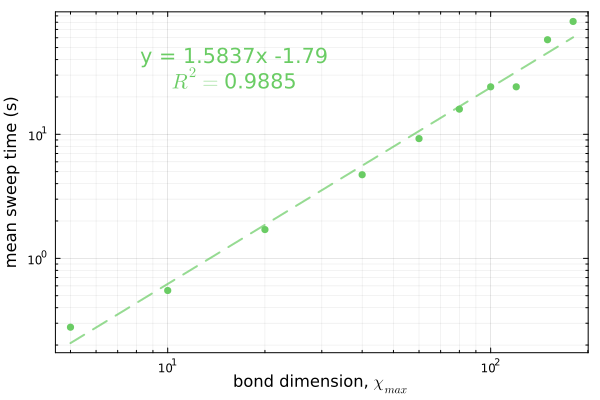

In [441]:
p3 = plot(chis, fitted_times3, label=:none, linewidth=2, color=seaborn_muted[3], alpha=0.7, ls=:dash)
scatter!(chis, mean_sweep_time_varying_chi, label=:none, xscale=:log10, yscale=:log10,
    xlabel="bond dimension, " * L"χ_{max}", ylabel="mean sweep time (s)", msw=0, c=seaborn_muted[3], minorgrid=true,border=:box)
annotate!(16, 35, text("y = $(round(slope3; digits=4))x $(round(intercept3; digits=4))\n" *L"R^2 = " * "$(round(r2val3; digits=4))", seaborn_muted[3]))

# d scaling

In [392]:
exp_4_f = jldopen("d_scaling_NTS1.jld2", "r");
per_trial_res_exp4 = read(exp_4_f, "per_trial_res_exp4")
ds = [3, 5, 8, 10, 13, 16, 19, 23]
d_res_dict = Dict()
d_res_dict[3] = [per_trial_res_exp3[trial][1][2:end-1] for trial in 1:3]
d_res_dict[5] = [per_trial_res_exp3[trial][2][2:end-1] for trial in 1:3]
d_res_dict[8] = [per_trial_res_exp3[trial][3][2:end-1] for trial in 1:3]
d_res_dict[10] = [per_trial_res_exp3[trial][4][2:end-1] for trial in 1:3]
d_res_dict[13] = [per_trial_res_exp3[trial][5][2:end-1] for trial in 1:3]
d_res_dict[16] = [per_trial_res_exp3[trial][6][2:end-1] for trial in 1:3]
d_res_dict[19] = [per_trial_res_exp3[trial][7][2:end-1] for trial in 1:3]
d_res_dict[23] = [per_trial_res_exp3[trial][8][2:end-1] for trial in 1:3]

3-element Vector{Vector{Float64}}:
 [2.5327870845794678, 25.34317898750305, 48.63316822052002, 48.603261947631836, 49.21522092819214]
 [2.8726000785827637, 25.878636121749878, 48.36350107192993, 48.518840074539185, 48.6344690322876]
 [2.2878429889678955, 18.70827317237854, 44.13335609436035, 45.03268480300903, 47.399927854537964]

In [211]:
d3_mean_per_trial = mean.(d_res_dict[3])
d3_mean = mean(d3_mean_per_trial)
d3_sem = std(d3_mean_per_trial)

d5_mean_per_trial = mean.(d_res_dict[5])
d5_mean = mean(d5_mean_per_trial)
d5_sem = std(d5_mean_per_trial)

d8_mean_per_trial = mean.(d_res_dict[8])
d8_mean = mean(d8_mean_per_trial)
d8_sem = std(d8_mean_per_trial)

d10_mean_per_trial = mean.(d_res_dict[10])
d10_mean = mean(d10_mean_per_trial)
d10_sem = std(d10_mean_per_trial)

d13_mean_per_trial = mean.(d_res_dict[13])
d13_mean = mean(d13_mean_per_trial)
d13_sem = std(d13_mean_per_trial)

d16_mean_per_trial = mean.(d_res_dict[16])
d16_mean = mean(d16_mean_per_trial)
d16_sem = std(d16_mean_per_trial)


d19_mean_per_trial = mean.(d_res_dict[19])
d19_mean = mean(d19_mean_per_trial)
d19_sem = std(d19_mean_per_trial)

d23_mean_per_trial = mean.(d_res_dict[23])
d23_mean = mean(d23_mean_per_trial)
d23_sem = std(d23_mean_per_trial)


1.9324867726604904

In [212]:
mean_sweep_time_varying_d = [d3_mean, d5_mean, d8_mean, d10_mean, d13_mean, d16_mean, d19_mean, d23_mean]
sem_sweep_time_varying_d = [d3_sem, d5_sem, d8_sem, d10_sem, d13_sem, d16_sem, d19_sem, d23_sem]
df4 = DataFrame(
    log_d = log10.(ds),
    log_mean_time = log10.(mean_sweep_time_varying_d)
)

Row,log_d,log_mean_time
,Float64,Float64
1,0.477121,-0.555117
2,0.69897,-0.259342
3,0.90309,0.231875
4,1.0,0.67391
5,1.11394,0.965116
6,1.20412,1.20259
7,1.27875,1.38263
8,1.36173,1.52819


In [393]:
model4 = lm(@formula(log_mean_time ~ log_d), df4);
fitted_log_times4 = predict(model4)
fitted_times4 = 10 .^ fitted_log_times4;
@show slope4 = coef(model4)[2]
@show intercept4 = coef(model4)[1]
@show r2val4 = r2(model4)[1]

slope4 = (coef(model4))[2] = 2.537769938230441
intercept4 = (coef(model4))[1] = -1.9035059039135576
r2val4 = (r2(model4))[1] = 0.9836071770600937


0.9836071770600937

In [230]:
cool_palette = ColorSchemes.cool
ten_colors = get.(Ref(cool_palette), range(0, 1, length=10))

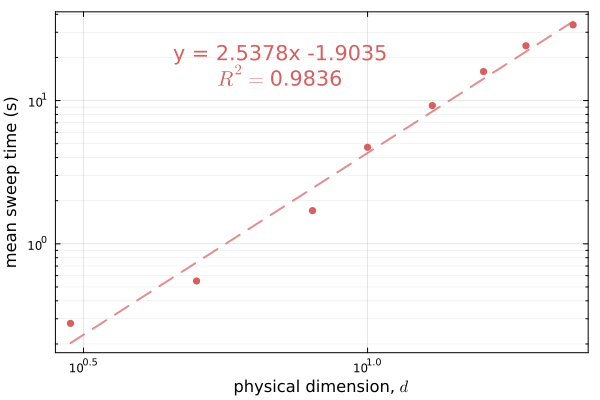

In [454]:
p4 = plot(ds, fitted_times4, label=:none, linewidth=2, color=seaborn_muted[4], alpha=0.7, ls=:dash)
scatter!(ds, mean_sweep_time_varying_d, label=:none, xscale=:log10, yscale=:log10,
    xlabel="physical dimension, "* L"d", ylabel="mean sweep time (s)", msw=0, c=seaborn_muted[4], minorgrid=true,
    border=:box)
annotate!(7, 18, text("y = $(round(slope4; digits=4))x $(round(intercept4; digits=4))\n" * L"R^2 = "* "$(round(r2val4; digits=4))", seaborn_muted[4]))

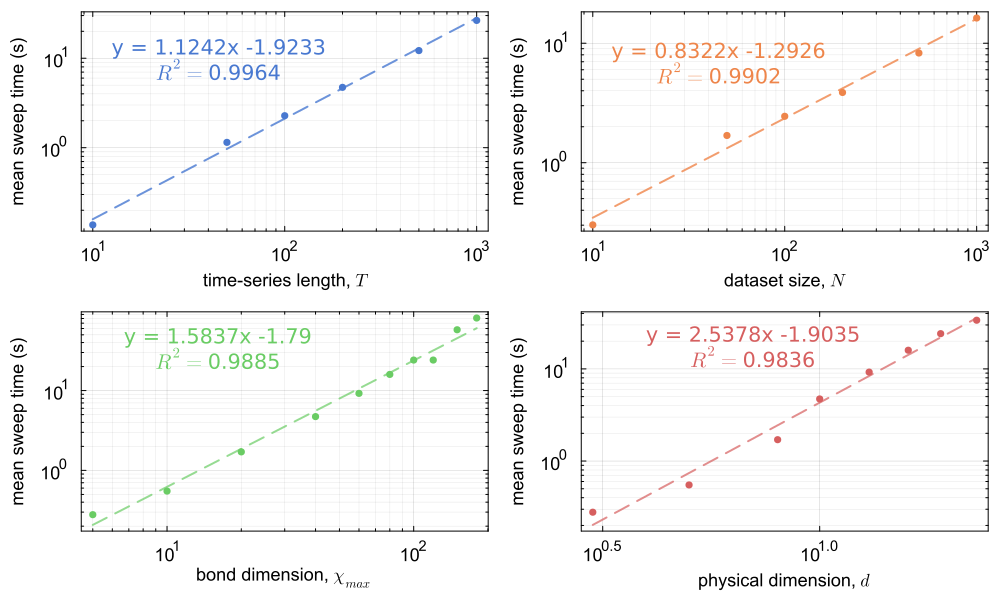

In [456]:
fstyle = font("arial", 12)
plot(p1, p2, p3, p4, size=(1000, 600), bottom_margin=5mm, left_margin=5mm, xtickfont=fstyle, ytickfont=fstyle, guidefont=fstyle)

In [446]:
#savefig("mpstime_scaling_behaviour.svg")